In [1]:
import sys,os
sys.path.append('../../')
os.environ["JAX_PLATFORMS"] = "cpu"
import matplotlib.pyplot as plt
import numpy as np
from utils import makefolder,depths,reduce_list_half_preserve_extremes

from geometry import * 

eps = 1E-7
rcpsize = 14
plt.rcParams['xtick.labelsize']= rcpsize
plt.rcParams['ytick.labelsize']=rcpsize
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = rcpsize
plt.rcParams.update({'figure.autolayout': True})
#colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['ggplot']['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['seaborn-v0_8']['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['seaborn-v0_8-dark-palette']['axes.prop_cycle'].by_key()['color']
from cycler import cycler
plt.rcParams['axes.prop_cycle'] = cycler(color=colors)
# print(plt.rcParams.keys())
#np.set_printoptions(precision=None)
markers = ['p','o','h','^','s','*']
_linestyles = ['-','--','dotted']
plot_id = 0

/home/acevedo/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# modelA = 'deepseek'
# modelA = 'qwen7b'
modelA = 'gemma12b'
modelB = modelA
language = 'english'

layers_A = list(range(1,depths[modelA] + 1))
layers_B = list(range(1,depths[modelB] + 1))
layers = np.array(reduce_list_half_preserve_extremes(layers_A),dtype=float)
layers /= depths[modelB]

batch_shuffle = 0
centers_var = 'syn'
n_files = 21
batch_size = 100
avg_flags = [0,1]
Nbits = 0
match_var = 'matching'
data_var = 'sem'
zero_activations_list = [0]
center_A_flags = [0,1,-1]
center_B_flag = 0

similarity_fn = 'normalized_L2_distance'

FileNotFoundError: [Errno 2] No such file or directory: './results/global_centering_0/spaces_AB/similarity_fn_normalized_L2_distance/precision_32/language_english/data_var_sem/modelA_gemma12b/modelB_gemma12b/match_var_matching/n_files_21/min_token_length_3/centers_syn/Nbits_0/n_tokens_3/avg_tokens_0/batch_shuffle_0/zero_activations_0/center_A_flag_0/center_B_flag_0/II_0.50.npy'

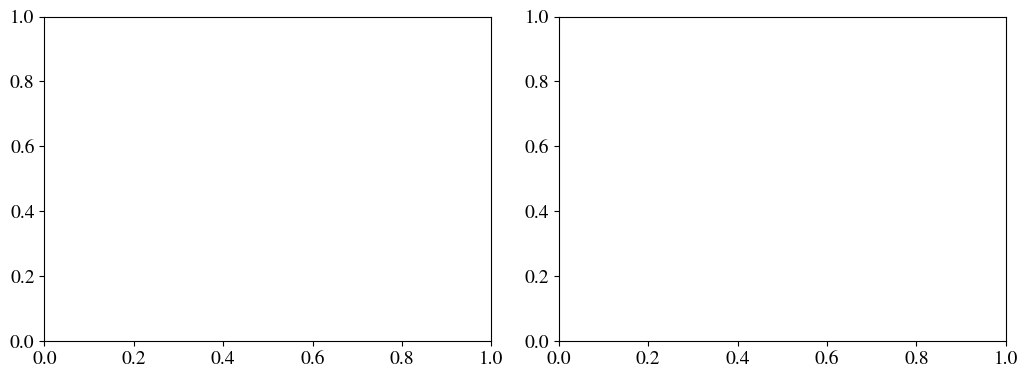

In [3]:
precision = 32
global_centering = 0
ratio_jackknife = .5

fig,ax = plt.subplots(1,2,figsize=(10.5,4))
title = ''

for avg_id,avg_tokens in enumerate(avg_flags):
    plot_id = 0
    min_token_length = 3
    n_tokens = min_token_length

    for removal_method_0 in [None,'projection']:
        for zero_id,zero_activations in enumerate(zero_activations_list):
          for center_A_id,center_A_flag in enumerate(center_A_flags):
              if center_A_flag == 0 and (removal_method_0 != None ):
                continue
              if removal_method_0 == None and (center_A_flag != 0):
                continue

              output_folder0 = makefolder(base=f'./results/',
                                          global_centering=global_centering,
                                          spaces='AB',
                                          similarity_fn=similarity_fn,
                                          precision=precision,
                                          language=language,
                                          data_var=data_var,
                                          modelA=modelA,
                                          modelB=modelB,
                                          match_var=match_var,
                                          n_files=n_files,
                                          min_token_length=min_token_length,
                                          )
              II_folder = makefolder(base=output_folder0,
                                                centers=centers_var,
                                                Nbits=Nbits,
                                                n_tokens=n_tokens,
                                                avg_tokens=avg_tokens,
                                                batch_shuffle=batch_shuffle,
                                                zero_activations=zero_activations,
                                                center_A_flag=center_A_flag,
                                                center_B_flag=center_B_flag,
                                                removal_method=removal_method_0,
                                                )
              inf_imb = 1 - np.load(II_folder + f"II_{ratio_jackknife:.2f}.npy").mean(axis=0)
              std = np.load(II_folder + f"II_jack_std_{ratio_jackknife:.2f}.npy").mean(axis=0)
              layers_A = list(range(1,depths[modelA] + 1))
              layers_B = list(range(1,depths[modelB] + 1))
              layers = np.array(reduce_list_half_preserve_extremes(layers_A),dtype=float)
              layers /= depths[modelB]
              color = colors[plot_id%len(colors)] 
              linestyle = '-'
              if avg_tokens:
                title = f'Average'
              else:
                title = f'Concatenation'


              label = ''
              if center_A_flag == 0:
                # label += r'$\mathbf{X}_i \rightarrow \mathbf{P}_i$'
                label += 'paraphrases'
              if center_A_flag == 1:
                # label += r'$\mathbf{X}_i \perp \mathbf{S}_i \rightarrow \mathbf{P}_i $'
                label += 'syntax-ablated paraphrases'
              if center_A_flag == -1:
                # label += r'$\mathbf{X}_i \perp \mathbf{S}_r \rightarrow \mathbf{P}_i$'
                label += 'random-ablated paraphrases'
                
              ax[avg_id].plot(
                  layers,
                  inf_imb.diagonal(),
                  label=label,
                  color=color,
                  marker='o',                # circular marker
                  markersize=5,              # tweakable size
                  markerfacecolor=color,     # fill same as line
                  markeredgecolor='black',   # cute black border
                  markeredgewidth=0.8,       # adjust border thickness
              )
              ax[avg_id].fill_between(layers,
                              inf_imb.diagonal() - std.diagonal(),
                              inf_imb.diagonal() + std.diagonal(),
                              alpha=0.2,
                              color=color,
                              )
              plot_id += 1

    ax[avg_id].set_xlabel('relative depth')
    # ax[avg_id].set_ylim(0.05,.8)
    ax[avg_id].set_ylim(0.05,.9)

    ax[avg_id].tick_params(
      top=True, bottom=True, left=True, right=True,  # enable ticks
      labeltop=False, labelbottom=True, labelleft=True, labelright=False, # enable labels if needed
      direction='in'  # ticks point inward
      )
    ax[avg_id].grid()
    ax[avg_id].set_title(title)

# Inner legends in both subplots
for a in ax[:1]:
    handles, labels = [], []
    for line in a.get_lines():
        label = line.get_label()
        if label:
            handles.append(line)
            labels.append(label)
    a.legend(handles, labels, loc='best', fontsize=rcpsize, framealpha=0.8)


# Add panel labels
panel_labels = ['a)', 'b)']
for i, label in enumerate(panel_labels):
    ax[i].text(
        -0.1, 1.05,      # x, y in axis coordinates
        label,
        transform=ax[i].transAxes,  # coordinates relative to the axes
        fontsize=16,
        fontweight='bold',
        va='top',
        ha='right'
    )

ax[0].set_ylabel('Similarity')
# ax[1].legend()
figsfolder = 'results/figs/decoupling'
os.makedirs(figsfolder, exist_ok=True)
fig.savefig(f'{figsfolder}/decoupling_syn_from_sem_{modelA}.pdf', bbox_inches='tight')
plt.show()

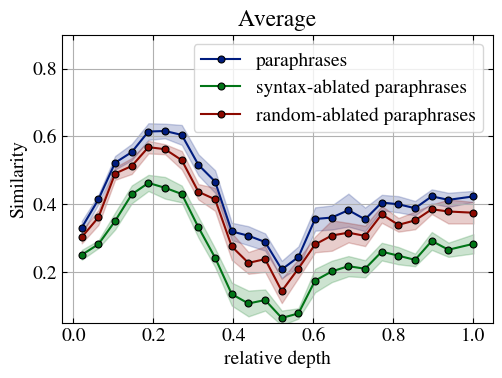

In [4]:
figsfolder = 'results/figs/decoupling'
os.makedirs(figsfolder, exist_ok=True)

for avg_id, avg_tokens in enumerate([1]):
    # New figure for this panel only
    fig_single, ax_single = plt.subplots(1, 1, figsize=(5.25, 4))

    min_token_length = 3
    n_tokens = min_token_length
    plot_id = 0

    for removal_method_0 in [None, 'projection']:
        for zero_id, zero_activations in enumerate(zero_activations_list):
            for center_A_id, center_A_flag in enumerate(center_A_flags):
                if center_A_flag == 0 and (removal_method_0 is not None):
                    continue
                if removal_method_0 is None and (center_A_flag != 0):
                    continue

                output_folder0 = makefolder(
                    base=f'./results/',
                    global_centering=global_centering,
                    spaces='AB',
                    similarity_fn=similarity_fn,
                    precision=precision,
                    language=language,
                    data_var=data_var,
                    modelA=modelA,
                    modelB=modelB,
                    match_var=match_var,
                    n_files=n_files,
                    min_token_length=min_token_length,
                )
                II_folder = makefolder(
                    base=output_folder0,
                    centers=centers_var,
                    Nbits=Nbits,
                    n_tokens=n_tokens,
                    avg_tokens=avg_tokens,
                    batch_shuffle=batch_shuffle,
                    zero_activations=zero_activations,
                    center_A_flag=center_A_flag,
                    center_B_flag=center_B_flag,
                    removal_method=removal_method_0,
                )

                inf_imb = 1-np.load(II_folder + f"II_{ratio_jackknife:.2f}.npy").mean(axis=0)
                std = np.load(II_folder + f"II_jack_std_{ratio_jackknife:.2f}.npy").mean(axis=0)
                layers_A = list(range(1, depths[modelA] + 1))
                layers_B = list(range(1, depths[modelB] + 1))
                layers = np.array(reduce_list_half_preserve_extremes(layers_A), dtype=float)
                layers /= depths[modelB]

                color = colors[plot_id % len(colors)]
                linestyle = '-'

                if avg_tokens:
                    title = 'Average'
                    avg_tag = 'avg'
                else:
                    title = 'Concatenation'
                    avg_tag = 'concat'

                label = ''
                if center_A_flag == 0:
                    label += 'paraphrases'
                if center_A_flag == 1:
                    label += 'syntax-ablated paraphrases'
                if center_A_flag == -1:
                    label += 'random-ablated paraphrases'

                ax_single.plot(
                    layers,
                    inf_imb.diagonal(),
                    label=label,
                    color=color,
                    marker='o',
                    markersize=5,
                    markerfacecolor=color,
                    markeredgecolor='black',
                    markeredgewidth=0.8,
                )
                ax_single.fill_between(
                    layers,
                    inf_imb.diagonal() - std.diagonal(),
                    inf_imb.diagonal() + std.diagonal(),
                    alpha=0.2,
                    color=color,
                )

                plot_id += 1

    # Axis cosmetics
    ax_single.set_xlabel('relative depth')
    ax_single.set_ylabel('Similarity')
    ax_single.set_ylim(0.05, 0.9)
    ax_single.tick_params(
        top=True, bottom=True, left=True, right=True,
        labeltop=False, labelbottom=True, labelleft=True, labelright=False,
        direction='in'
    )
    ax_single.grid()
    ax_single.set_title(title)

    # Legend for this single panel
    handles, labels = [], []
    for line in ax_single.get_lines():
        lab = line.get_label()
        if lab:
            handles.append(line)
            labels.append(lab)
    ax_single.legend(handles, labels, loc='best', fontsize=rcpsize, framealpha=0.8)

    # Save with avg_tokens info in the filename
    # e.g. decoupling_syn_from_sem_Llama-3_avg.pdf / _concat.pdf
    fig_single.savefig(
        f'{figsfolder}/decoupling_syn_from_sem_{modelA}_{avg_tag}.pdf',
        bbox_inches='tight'
    )
    plt.show()
    plt.close(fig_single)


In [ ]:
precision = 32
global_centering = 0
ratio_jackknife = .5

fig,ax = plt.subplots(1,2,figsize=(8,4))
title = ''

for avg_id,avg_tokens in enumerate(avg_flags):
    plot_id = 0
    min_token_length = 3
    n_tokens = min_token_length

    for removal_method_0 in [None,'projection']:
        _removal_method = 'projection' if removal_method_0 == 'projection' else 'center'
        for zero_id,zero_activations in enumerate(zero_activations_list):
          for center_A_id,center_A_flag in enumerate(center_A_flags):
              if center_A_flag == 0 and (removal_method_0 != None ):
                continue
              if removal_method_0 == None and (center_A_flag != 0):
                continue

              output_folder0 = makefolder(base=f'./results/',
                                          global_centering=global_centering,
                                          spaces='AB',
                                          similarity_fn=similarity_fn,
                                          precision=precision,
                                          language=language,
                                          data_var=data_var,
                                          modelA=modelA,
                                          modelB=modelB,
                                          match_var=match_var,
                                          n_files=n_files,
                                          min_token_length=min_token_length,
                                          )
              II_folder = makefolder(base=output_folder0,
                                                centers=centers_var,
                                                Nbits=Nbits,
                                                n_tokens=n_tokens,
                                                avg_tokens=avg_tokens,
                                                batch_shuffle=batch_shuffle,
                                                zero_activations=zero_activations,
                                                center_A_flag=center_A_flag,
                                                center_B_flag=center_B_flag,
                                                removal_method=removal_method_0,
                                                )
              corr_coeff = np.load(II_folder + f"corr_coeff_{ratio_jackknife:.2f}.npy")
              try:
                std = np.load(II_folder + f"corr_coeff_jack_std_{ratio_jackknife:.2f}.npy") 
              except:
                std = np.zeros_like(corr_coeff)

              layers_A = list(range(1,depths[modelA] + 1))
              layers_B = list(range(1,depths[modelB] + 1))
              layers = np.array(reduce_list_half_preserve_extremes(layers_A),dtype=float)
              layers /= depths[modelB]
              color = colors[plot_id%len(colors)] 
              linestyle = '-'
              if avg_tokens:
                title = f'Average'
              else:
                title = f'Concatenation'


              label = ''
              if center_A_flag == 0:
                # label += r'$\mathbf{X}_i \rightarrow \mathbf{P}_i$'
                label += 'paraphrases'
              if center_A_flag == 1:
                # label += r'$\mathbf{X}_i \perp \mathbf{S}_i \rightarrow \mathbf{P}_i $'
                label += 'syntax-ablated paraphrases'
              if center_A_flag == -1:
                # label += r'$\mathbf{X}_i \perp \mathbf{S}_r \rightarrow \mathbf{P}_i$'
                label += 'random-ablated paraphrases'
                
              for II_index in range(1):
                if II_index == 1:
                  label = None
                ax[avg_id].plot(
                    layers,
                    corr_coeff[II_index].diagonal(),
                    label=label,
                    linestyle=_linestyles[II_index],
                    color=color,
                    marker='o',                # circular marker
                    markersize=5,              # tweakable size
                    markerfacecolor=color,     # fill same as line
                    markeredgecolor='black',   # cute black border
                    markeredgewidth=0.8,       # adjust border thickness
                )
                ax[avg_id].fill_between(layers,
                                corr_coeff[II_index].diagonal() - std[II_index].diagonal(),
                                corr_coeff[II_index].diagonal() + std[II_index].diagonal(),
                                alpha=0.2,
                                color=color,
                                )
              plot_id += 1

    ax[avg_id].set_xlabel('relative depth')

    ax[avg_id].tick_params(
      top=True, bottom=True, left=True, right=True,  # enable ticks
      labeltop=False, labelbottom=True, labelleft=True, labelright=False, # enable labels if needed
      direction='in'  # ticks point inward
      )
    ax[avg_id].grid()
    ax[avg_id].set_title(title)

# Inner legends in both subplots
for a in ax[:1]:
    handles, labels = [], []
    for line in a.get_lines():
        label = line.get_label()
        if label:
            handles.append(line)
            labels.append(label)
    a.legend(handles, labels, loc='best', fontsize=rcpsize, framealpha=0.8)


# Add panel labels
panel_labels = ['a)', 'b)']
for i, label in enumerate(panel_labels):
    ax[i].text(
        -0.1, 1.05,      # x, y in axis coordinates
        label,
        transform=ax[i].transAxes,  # coordinates relative to the axes
        fontsize=16,
        fontweight='bold',
        va='top',
        ha='right'
    )

# After plotting everything, compute global min and max
all_mins, all_maxs = [], []

for avg_id in range(2):
    for line in ax[avg_id].get_lines():
        ydata = line.get_ydata()
        all_mins.append(np.min(ydata)*.8)
        all_maxs.append(np.max(ydata)*1.2)

global_min = min(all_mins)
global_max = max(all_maxs)

# Optionally, add some margin
margin = 0.05 * (global_max - global_min)
global_min -= margin
global_max += margin

# Set same ylims for both subplots
for avg_id in range(2):
    ax[avg_id].set_ylim(global_min, global_max)

    
ax[0].set_ylabel("Chatterjee's mean ξ")

# ax[1].legend()
fig.savefig(f'{figsfolder}/decoupling_syn_from_sem_{modelA}_corr.pdf', bbox_inches='tight')
plt.show()

In [ ]:
# precision = 32
# global_centering = 0

# fig,ax = plt.subplots(1,2,figsize=(8,4))
# title = ''
# ax_id = -1
# plot_id = 0

# for removal_method_0 in [None,'projection',None,'subtraction']:
#     if removal_method_0 == None: 
#       ax_id += 1
#       plot_id = 0
#     _removal_method = 'projection' if removal_method_0 == 'projection' else 'center'
#     for zero_id,zero_activations in enumerate(zero_activations_list):
#       for center_A_id,center_A_flag in enumerate(center_A_flags):
#         for center_B_id,center_B_flag in enumerate(center_B_flags):

#           if center_A_flag == 0 and (removal_method_0 != None ):
#             continue
#           if removal_method_0 == None and (center_A_flag != 0):
#             continue

#           output_folder0 = makefolder(base=f'./results/',
#                                       global_centering=global_centering,
#                                       spaces='AB',
#                                       similarity_fn=similarity_fn,
#                                       precision=precision,
#                                       language=language,
#                                       data_var=data_var,
#                                       modelA=modelA,
#                                       modelB=modelB,
#                                       match_var=match_var,
#                                       n_files=n_files,
#                                       min_token_length=min_token_length,
#                                       )
#           II_folder = makefolder(base=output_folder0,
#                                             centers=centers_var,
#                                             Nbits=Nbits,
#                                             n_tokens=n_tokens,
#                                             avg_tokens=avg_tokens,
#                                             batch_shuffle=batch_shuffle,
#                                             zero_activations=zero_activations,
#                                             center_A_flag=center_A_flag,
#                                             center_B_flag=center_B_flag,
#                                             removal_method=removal_method_0,
#                                             )
#           inf_imb = np.load(II_folder + f"II.npy")
#           std = np.load(II_folder + f"II_jack_std.npy")

#           color = colors[plot_id%len(colors)] 
#           linestyle = '-'
#           if removal_method_0 != None:
#             title = f'{removal_method_0}'


#           label = ''
#           if center_A_flag == 0:
#             label += 'semantic similarity'
#           if center_A_flag == 1:
#             label += f' syntax {_removal_method}'
#           if center_A_flag == -1:
#             label += f'random {_removal_method}s'
            
#           for II_index in range(2):
#             if II_index == 1:
#               label = None
#             ax[ax_id].plot(layers,
#                     inf_imb[II_index].diagonal(),
#                     label=label,
#                     linestyle=_linestyles[II_index],
#                     color=color,
#                     ) 
#             ax[ax_id].fill_between(layers,
#                             inf_imb[II_index].diagonal() - std[II_index].diagonal(),
#                             inf_imb[II_index].diagonal() + std[II_index].diagonal(),
#                             alpha=0.2,
#                             color=color,
#                             )
#           plot_id += 1

#     ax[ax_id].set_xlabel('relative depth')
#     ax[0].set_ylabel('II')
#     ax[ax_id].set_ylim(0.1,.8)
#     ax[ax_id].tick_params(
#       top=True, bottom=True, left=True, right=True,  # enable ticks
#       labeltop=False, labelbottom=True, labelleft=True, labelright=False, # enable labels if needed
#       direction='in'  # ticks point inward
#       )
#     ax[ax_id].grid()
#     ax[ax_id].set_title(title)


# fig.suptitle(f' {modelA} | English paraphrases')

# box = ax[ax_id].get_position()
# ax[ax_id].set_position([box.x0, box.y0, box.width * 0.8, box.height])
# ax[ax_id].legend(loc='center left', bbox_to_anchor=(1, 0.5))

# os.makedirs('results/figs', exist_ok=True)
# # fig.savefig(f'results/figs/decoupling_sem_syn_{modelA}_avg_{avg_tokens}.pdf', bbox_inches='tight')
# plt.show()